<p style='text-align: center;'>

## <p style='text-align: center;'> **This is the Notebook for the CIFO Project**

### <p style='text-align: center;'> **Group: C37 Vestigial**




In [1]:
# Numerical arrays and vectorized operations used for triangle genomes and RMSE calculations.
import numpy as np

# Plotting library used to show final images and convergence curves inside the notebook.
import matplotlib.pyplot as plt

# Random utilities used by the genetic algorithm: initialization, selection, and mutation.
from random import randint, choices, sample, random

# OpenCV is used to load images, draw filled triangles, and save generated outputs.
import cv2

# ABC/abstractmethod are used to define a generic optimization solution template.
from abc import ABC, abstractmethod

# deepcopy prevents offspring/elites from accidentally sharing the same object in memory as parents.
from copy import deepcopy

In [9]:
class Solution(ABC):
    """Generic abstract class for an optimization solution."""

    def __init__(self, repr=None):
        # If no representation is provided, create a random one using the subclass method.
        if repr == None:
            repr = self.random_initial_representation()

        # Store the representation/genome of the solution.
        self.repr = repr

    def __repr__(self):
        # Defines how the solution is displayed when printed.
        return str(self.repr)

    @abstractmethod
    def fitness(self):
        # Every specific solution must define how quality/fitness is calculated.
        pass

    @abstractmethod
    def random_initial_representation(self):
        # Every specific solution must define how a random starting solution is created.
        pass

In [10]:
class VermeerSolution(Solution):
    """A candidate painting made from 100 colored triangles."""

    def __init__(self, target_image, repr=None):
        # Store the original image that the generated triangle image will be compared against.
        self.target_image = target_image

        # Project canvas size: 300x400 pixels.
        self.width = 300
        self.height = 400

        # Project requirement: use 100 triangles.
        self.num_triangles = 100

        # Calls Solution.__init__, which either stores a provided repr or creates a random one.
        super().__init__(repr=repr)

    def random_initial_representation(self):
        """
        Generates a random genome of 100 small triangles.
        Each row has: [x1, y1, x2, y2, x3, y3, r, g, b]
        """

        # Matrix with one row per triangle and 9 values per triangle.
        random_repr = np.zeros((self.num_triangles, 9), dtype=int)

        for i in range(self.num_triangles):
            # Pick a random center points in the canvas for the triangle
            cx = randint(0, self.width)
            cy = randint(0, self.height)

            # Define an max radius for the triangles
            radius = 40
            # Generate 3 random x-coordinates and 3 random y-coordinates within the range of the defined radius
            # This allows to control the size of the randomly intialized traingles (can start with small triangles)
            x1 = np.clip(cx + randint(-radius, radius), 0, self.width)
            y1 = np.clip(cy + randint(-radius, radius), 0, self.height)
            x2 = np.clip(cx + randint(-radius, radius), 0, self.width)
            y2 = np.clip(cy + randint(-radius, radius), 0, self.height)
            x3 = np.clip(cx + randint(-radius, radius), 0, self.width)
            y3 = np.clip(cy + randint(-radius, radius), 0, self.height)
            # Generate one random RGB color for the whole triangle.
            r, g, b = [randint(0, 255) for _ in range(3)]
            # Store the triangle's vertices and color in the genome.
            random_repr[i] = [x1, y1, x2, y2, x3, y3, r, g, b]

        return random_repr

    def render_canvas(self):
        """Converts the 100-triangle genome into an actual image matrix."""

        # Start from a black image with shape: height x width x RGB channels.
        canvas = np.zeros((self.height, self.width, 3), dtype=np.uint8)

        for gene in self.repr:
            # Extract the three triangle vertices in OpenCV's expected format.
            pts = np.array(
                [[gene[0], gene[1]], [gene[2], gene[3]], [gene[4], gene[5]]], np.int32
            )

            # Reshape points so cv2.fillPoly can draw the triangle.
            pts = pts.reshape((-1, 1, 2))

            # Extract the triangle color.
            # NOTE: The loaded OpenCV image is BGR, but the project logic treats these as channel values consistently.
            color = (int(gene[6]), int(gene[7]), int(gene[8]))

            # Draw a filled triangle on the canvas.
            cv2.fillPoly(canvas, [pts], color)

        return canvas

    def fitness(self):
        """Calculates RMSE between the target image and the generated triangle image.
        Applies a small penalty to overlapping triangles in order to try and resolve the problem with facial features
        """

        # Render this individual's genome into an image.
        generated_image = self.render_canvas()

        # Convert to float before subtracting, avoiding uint8 overflow/underflow errors.
        target_float = self.target_image.astype(np.float32)
        gen_float = generated_image.astype(np.float32)

        # Pixel-by-pixel difference between target and generated image.
        diff = target_float - gen_float
        # RMSE = sqrt(mean(square(error))). Lower RMSE means a better image.
        sq_diff = np.square(diff)
        mse = np.mean(sq_diff)
        rmse = np.sqrt(mse)

        # The final fitness is the visual error PLUS the geometric penalty
        return rmse

In [11]:
# Path to João's local copy of the target image.
joao_path = r"C:\Users\joaoa\Desktop\CIFO\data\girl_pearl_earing.png"
goncalo_path = r"C:\CIfO\Project\data\girl_pearl_earing.png"
# Load the original image using OpenCV.
original_image = cv2.imread(goncalo_path)

# Fail early with a clear error if the path is wrong or the image cannot be read.
if original_image is None:
    raise FileNotFoundError(f"OpenCV could not find the image at: {joao_path}")

# Create one random triangle painting to test the VermeerSolution class.
first_painting = VermeerSolution(
    target_image=original_image
)

# Print its genome and RMSE fitness to confirm the representation and fitness function work.
print(f"{first_painting.repr} has fitness {first_painting.fitness()}")

[[ 54 181  99 194  39 186 164 253  35]
 [193 385 202 338 202 370  83 162  97]
 [ 33  22  52  67  14  63 182 143  53]
 [271  61 241  58 283  36 177  88 160]
 [ 41 156   0 142  54 209 246  28  97]
 [ 49 320  29 318  72 297  50  33 137]
 [ 88 110 111 112 139  75  80 110 110]
 [ 80 246  68 275  83 302  43  94  60]
 [112 215  75 157 130 199 217  99   9]
 [ 34 222  70 193  75 203  50  47 146]
 [ 78 174  72 185  82 181 249 115  81]
 [ 53 300 111 325 105 298  90  87  76]
 [115 120 137 102 150  65 140 221 101]
 [206   0 168   0 170  27  90  29  20]
 [251 366 201 389 211 400  90 148  85]
 [210 256 239 239 200 215 211  93 203]
 [287 400 257 400 283 400 194 178  59]
 [198 132 143 166 180 194  49 117  78]
 [ 66 181 123 232 125 200 138 106 106]
 [ 57 220  58 208  80 217  90 189 239]
 [235 160 238 184 261 154 249 135  11]
 [256  59 210  82 254 100  73 210 235]
 [ 14 227  37 191  21 206 235  67 133]
 [295 237 265 243 280 257  10   8 227]
 [244 400 203 400 189 390 137 187 196]
 [116  44 122  70 117 115

Now to test out if the initial class functions in producing an image and comparing it to the original painting

In [12]:
"""gonçalo_path = 'C:\CIfO\Project\data\girl_pearl_earing.png'

original_vermeer = cv2.imread(r'C:\CIfO\Project\data\girl_pearl_earing.png')

my_first_painting = VermeerSolution(target_image=original_vermeer)

score = round(my_first_painting.fitness(), 2)

print(f'The RMSE Score of random painting is: {score}')"""

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\gpape\AppData\Local\Temp\ipykernel_25012\2867555573.py:1: SyntaxWarning: invalid escape sequence '\C'
  """gonçalo_path = 'C:\CIfO\Project\data\girl_pearl_earing.png'


"gonçalo_path = 'C:\\CIfO\\Project\\data\\girl_pearl_earing.png'\n\noriginal_vermeer = cv2.imread(r'C:\\CIfO\\Project\\data\\girl_pearl_earing.png')\n\nmy_first_painting = VermeerSolution(target_image=original_vermeer)\n\nscore = round(my_first_painting.fitness(), 2)\n\nprint(f'The RMSE Score of random painting is: {score}')"

### New Implementation of the GA with upgrades Mutation, Crossover and Elitism

In [ ]:
class VermeerGA2:
    """Improved Genetic Algorithm with uniform crossover, richer mutation, elitism, and optional saving."""

    def __init__(
        self,
        target_image,
        pop_size=200,
        generations=1000,
        pc=0.85,
        pm=0.03,
        elitism_size=1,
        tournament_size=3,
        use_crossover=True,
        use_mutation=True,
        use_fitness_sharing=False,
        variance_threshold=450,
        save_every=None,
        output_dir=None,
    ):
        # Target image used by the RMSE fitness function.
        self.target_image = target_image

        # Population and run-length parameters.
        self.pop_size = pop_size
        self.generations = generations

        # Crossover probability and mutation probability.
        self.pc = pc
        self.pm = pm

        # Number of best individuals copied unchanged into the next generation.
        self.elitism_size = elitism_size

        # Number of candidates used in tournament selection.
        self.tournament_size = tournament_size

        # Switches used for Challenge 3 ablation experiments.
        self.use_crossover = use_crossover
        self.use_mutation = use_mutation

        # Fitness sharing for Premature Convergence
        self.use_fitness_sharing = use_fitness_sharing
        self.variance_threshold = variance_threshold

        # Optional controls for saving intermediate images.
        self.save_every = save_every
        self.output_dir = output_dir

        # Initial random population.
        self.population = [
            VermeerSolution(
                target_image=self.target_image,
            )
            for _ in range(self.pop_size)
        ]

    def apply_fitness_sharing(self):
        """
        Implements Fitness Sharing with a sharing radius (radius_share) to create niches (species) 
        to penalize genotypic crowding and try to prevent premature convergence.
        """
        radius_share = 0.15 # Sharing radius (15% max dist)
        alpha = 1.0 # Scaling shape (1.0 = linear dropoff)
    
        # Flatten 100x9 matrices (repr of each solution) into flat arrays of length 900
        # This allows the comparison (distance) of these different solutions mathematically
        flat_reprs = np.vstack([ind.repr.flatten() for ind in self.population])

        # Distance Measure to calculate euclidean distance between all indivs 
        diff = flat_reprs[:, np.newaxis, :] - flat_reprs[np.newaxis, :, :]
        dist_matrix = np.sqrt(np.sum(diff**2, axis=-1))

        # Normalization Method (Normalize distance [0,1] where 0 is small dist, 1 is large dist
        min_dist = np.min(dist_matrix)
        max_dist = np.max(dist_matrix)
        if max_dist == min_dist:
            norm_dist_matrix = np.zeros_like(dist_matrix) # Safe against division by zero
        else:
            norm_dist_matrix = (dist_matrix - min_dist) / (max_dist - min_dist)
        
        # Invesion Matrix
        # Convert distance into similarity S(i, j)
        
        similarity_matrix = np.where(
            norm_dist_matrix < radius_share,
            1.0 - (norm_dist_matrix / radius_share) ** alpha,
            0.0
        )

        # Sum similarities for each indiv across their row
        niche_counts = np.sum(similarity_matrix, axis=1)

        # Redefine Matrix
        for idx, ind in enumerate(self.population):
            # Multiply (penalize) the RMSE of crowded solutions
            ind.shared_fitness = ind.fitness_score * niche_counts[idx]


    def evaluate_population(self):
        """Evaluate all individuals and sort population from best to worst RMSE."""

        # Always recalculate fitness after reproduction to avoid stale fitness values.
        for ind in self.population:
            if not hasattr(ind, 'fitness_score'):
                ind.fitness_score = ind.fitness()

        # Conditionally apply sharing and sort
        if self.use_fitness_sharing:
            self.apply_fitness_sharing()
            self.population.sort(key=lambda ind: ind.shared_fitness)
        else:
            # Lower RMSE is better, so ascending order places the best individual first.
            self.population.sort(key=lambda ind: ind.fitness_score)
        

    def tournament_selection(self):
        """Picks K random individuals and returns the one with the lowest RMSE."""

        # Randomly select tournament_size candidates.
        tournament = sample(self.population, self.tournament_size)

        if self.use_fitness_sharing:
            winner = sorted(tournament, key=lambda ind: ind.shared_fitness)[0]
        else:
            # The candidate with lowest RMSE wins the tournament.
            winner = sorted(tournament, key=lambda ind: ind.fitness_score)[0]
        return winner

    def crossover(self, parent1, parent2):
        """Uniform crossover: each triangle is inherited from either Parent 1 or Parent 2."""

        # Create a child object (random_representation of a solution(child)); then replace its genome using parent genes.
        child = VermeerSolution(
            target_image=self.target_image,
        )
        
        # Mask has one 0/1 value per triangle.
        # 1 means take triangle from parent1; 0 means take triangle from parent2.
        mask = np.random.randint(0, 2, size=(child.num_triangles, 1))

        # np.where applies the mask triangle by triangle.
        child.repr = np.where(mask, parent1.repr, parent2.repr).copy()
        
        return child

    def mutate(self, child):
        """Randomly mutates triangle coordinates, colors, or drawing order."""

        for i in range(child.num_triangles):
            # Each triangle has probability pm of being mutated.
            if random() < self.pm:

                # Decide which mutation operator to apply.
                mutation_type = random()

                if mutation_type < 0.80:
                    # 80% of mutations are small nudges to preserve useful structures.
                    child.repr[i][0:6] += np.random.randint(-10, 11, 6)  # coordinates
                    child.repr[i][6:9] += np.random.randint(-15, 16, 3)  # color

                    # Keep x-coordinates inside the image width.
                    child.repr[i][0] = np.clip(child.repr[i][0], 0, child.width)
                    child.repr[i][2] = np.clip(child.repr[i][2], 0, child.width)
                    child.repr[i][4] = np.clip(child.repr[i][4], 0, child.width)

                    # Keep y-coordinates inside the image height.
                    child.repr[i][1] = np.clip(child.repr[i][1], 0, child.height)
                    child.repr[i][3] = np.clip(child.repr[i][3], 0, child.height)
                    child.repr[i][5] = np.clip(child.repr[i][5], 0, child.height)

                    # Keep color channels valid.
                    child.repr[i][6:9] = np.clip(child.repr[i][6:9], 0, 255)

                elif mutation_type < 0.90:
                    # 10% of mutations fully replace one triangle, helping exploration.
                    child.repr[i] = [
                        randint(0, child.width),
                        randint(0, child.height),
                        randint(0, child.width),
                        randint(0, child.height),
                        randint(0, child.width),
                        randint(0, child.height),
                        randint(0, 255),
                        randint(0, 255),
                        randint(0, 255),
                    ]
                else:
                    # 10% of mutations swap triangle drawing order.
                    # This matters because later triangles can cover earlier triangles.
                    swap_idx = randint(0, child.num_triangles - 1)
                    child.repr[[i, swap_idx]] = child.repr[[swap_idx, i]]
        if hasattr(child, 'fitness_score'):
            del child.fitness_score

        return child
    
    def calculate_population_variance(self):
        """
        Calculates the Variance within a given Population to monitor for premature convergence.
        """
        measure_phenotypic = False
        measure_genotypic = True

        if measure_phenotypic:
            scores = [ind.fitness_score for ind in self.population]
            return np.var(scores)
        elif measure_genotypic:
            # Stack 200 paintings 'DNA' into a 200, 900 matrix
            flat_reprs = np.vstack([ind.repr.flatten() for ind in self.population])
            # Calculate variance of each of 900 genes across population
            gene_variances = np.var(flat_reprs, axis=0)
            return np.mean(gene_variances)
        return 0.0
            

    def maybe_save_generation(self, gen):
        """Optionally save the current best image every N generations."""

        # Do nothing if saving was not configured.
        if self.save_every is None or self.output_dir is None:
            return

        # Only save at selected intervals.
        if gen % self.save_every != 0:
            return

        # Create output folder if it does not already exist.
        import os

        os.makedirs(self.output_dir, exist_ok=True)

        # Save the current best image; population[0] is best because population is sorted.
        image = self.population[0].render_canvas()
        cv2.imwrite(f"{self.output_dir}/gen_{gen}.png", image)

    def run(self):
        """Main evolutionary loop."""

        print(f"Starting Evolution for {self.generations} generations...")

        # Stores the best RMSE at each generation for convergence analysis.
        fitness_history = []

        # Store fitness variance at each nth generations
        variance_history = []

        # Evaluate initial population before tournament selection starts.
        self.evaluate_population()

        for gen in range(self.generations):
            # Best individual is always first after sorting.
            best_current_solution = min(self.population, key=lambda ind: ind.fitness_score)

            # Store best RMSE for this generation.
            fitness_history.append(best_current_solution.fitness_score)

            # Calculate Population variance
            current_variance = self.calculate_population_variance()
            variance_history.append(current_variance)

            # Dynamic activaiton of Fitness Sharing to deal with Premature Convergence and increase diversity
            if current_variance < self.variance_threshold:
                if not self.use_fitness_sharing:
                    print(f"\n Variance dropped to {current_variance:.2f} Fitness Sharing Activated at Gen: {gen}")
                # Apply fitness sharing to the current population for tournament selection to being with new fitness values
                self.use_fitness_sharing = True
                self.apply_fitness_sharing()
            else:
                if self.use_fitness_sharing:
                    print(f"Variance rose to {current_variance:.2f} Fitness Sharing Deactivated at Gen: {gen}")
                self.use_fitness_sharing = False

            # Print progress, as well as population variance and optionally save image snapshots.
            if gen % 50 == 0:
                print(
                    f"Generation {gen} | Best RMSE: {best_current_solution.fitness_score:.2f} | Variance: {current_variance:.2f}"
                )
                self.maybe_save_generation(gen)

            # Elitism: copy the best k individuals directly to the next generation.
            next_generation = [
                deepcopy(ind) for ind in self.population[: self.elitism_size]
            ]

            # Generate children until the next population is full.
            while len(next_generation) < self.pop_size:

                # Select the first parent.
                p1 = self.tournament_selection()

                # With probability pc, create a child through crossover.
                # If crossover is disabled, clone p1 instead.
                if self.use_crossover and random() < self.pc:
                    p2 = self.tournament_selection()
                    child = self.crossover(p1, p2)
                else:
                    child = deepcopy(p1)

                # Apply mutation unless disabled for Challenge 3 experiments.
                if self.use_mutation:
                    child = self.mutate(child)

                # Add the new individual to the next generation.
                next_generation.append(child)

            # Replace old population with new generation.
            self.population = next_generation

            # Evaluate and sort all new individuals before the next generation.
            self.evaluate_population()

        # Final evaluation/sort for safety before returning.
        self.evaluate_population()

        print(f"Evolution Complete! Final RMSE: {self.population[0].fitness_score:.2f}")
        return self.population[0], fitness_history, variance_history

Results will be saved in: C:\CIfO\Project\data\results\Run14
Starting Evolution for 4000 generations...
Generation 0 | Best RMSE: 99.17 | Variance: 8973.93
Generation 50 | Best RMSE: 52.49 | Variance: 2316.36
Generation 100 | Best RMSE: 43.25 | Variance: 1176.62
Generation 150 | Best RMSE: 40.06 | Variance: 1024.55
Generation 200 | Best RMSE: 37.75 | Variance: 942.63
Generation 250 | Best RMSE: 36.08 | Variance: 1308.35
Generation 300 | Best RMSE: 34.96 | Variance: 780.55
Generation 350 | Best RMSE: 34.22 | Variance: 1038.61
Generation 400 | Best RMSE: 33.52 | Variance: 848.62
Generation 450 | Best RMSE: 32.96 | Variance: 853.38
Generation 500 | Best RMSE: 31.72 | Variance: 880.69
Generation 550 | Best RMSE: 30.76 | Variance: 791.14

 Variance dropped to 547.86 Fitness Sharing Activated at Gen: 583
Variance rose to 619.38 Fitness Sharing Deactivated at Gen: 584
Generation 600 | Best RMSE: 30.06 | Variance: 729.80
Generation 650 | Best RMSE: 29.70 | Variance: 705.61

 Variance dropped t

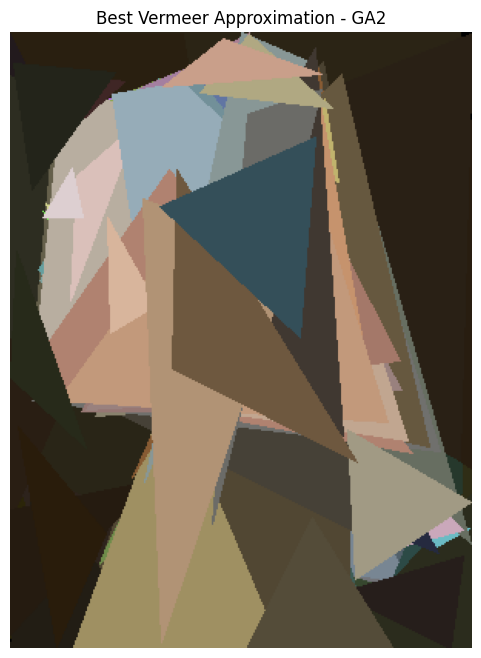

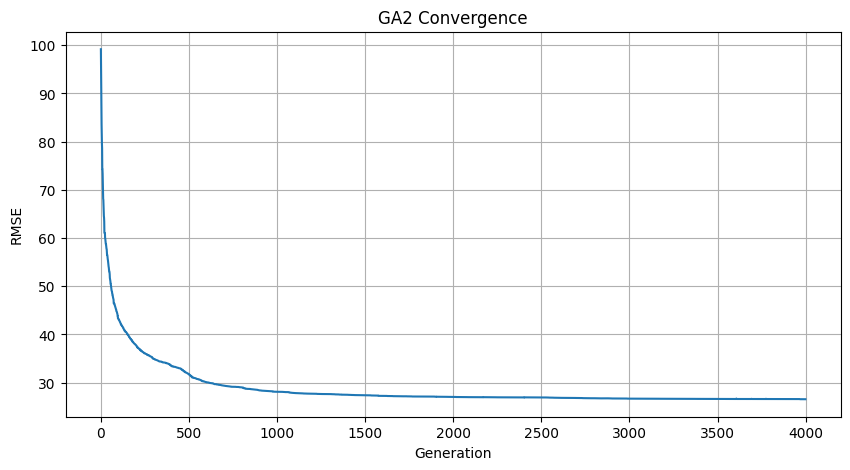

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
from random import random, randint, sample, seed

if __name__ == "__main__":

    # 1. Define Base Directory
    base_results_dir = r"C:\CIfO\Project\data\results"

    # Create base directory if it does not exist
    os.makedirs(base_results_dir, exist_ok=True)

    # 2. Create New Folder to be used for each run
    existing_runs = [
        folder
        for folder in os.listdir(base_results_dir)
        # Folders will be organized by the Nº of Run, so first folder will be the first trial Run then subsequent runs will be 2, 3, 4 ...
        if folder.startswith("Run")
    ]
    # Create list to track the number of runs performed
    run_numbers = []

    for folder in existing_runs:
        try:
            number = int(folder.replace("Run", ""))
            run_numbers.append(number)
        except:
            pass
    # Looks at the last run performed and adds the next run max(run_numbers, default=0) + 1
    next_run_number = max(run_numbers, default=0) + 1

    run_folder = os.path.join(base_results_dir, f"Run{next_run_number}")

    os.makedirs(run_folder, exist_ok=True)

    print(f"Results will be saved in: {run_folder}")

    # 3. Define Target image path
    goncalo_target_path = r"C:\CIfO\Project\data\girl_pearl_earing.png"

    # 4. Load Target Image

    target = cv2.imread(goncalo_target_path)

    if target is None:
        raise FileNotFoundError(
            f"OpenCV could not find the image at: {goncalo_target_path}"
        )

    # 5. Define Hyperparameters (These are changed in each different run for optimization, however they are saved at each run)

    pop_size = 200
    generations = 4000
    pc = 0.85
    pm = 0.03
    elitism_size = 10
    tournament_size = 4
    save_every = 500
    variance_threshold = 550
    use_fitness_sharing = False  
        
    SEED = 42
    seed(SEED)
    np.random.seed(SEED)
    
    # 6. Initialize GA
    ga = VermeerGA2(
        target_image=target,
        pop_size=pop_size,
        generations=generations,
        pc=pc,
        pm=pm,
        elitism_size=elitism_size,
        tournament_size=tournament_size,
        use_fitness_sharing=use_fitness_sharing,
        variance_threshold=variance_threshold,
        save_every=save_every,
        output_dir=run_folder,
    )

    seed()
    np.random.seed()

    best_painting, fitness_history, variance_history = ga.run()
    
    # Dictionary to store both fitness and variance values at each generation 
    history_dict = {}
    for gen in range(len(fitness_history)):
        history_dict[gen] = {
            'fitness': fitness_history[gen],
            'variance': variance_history[gen]
        }
    
    # 7. Creates a text file (hyperparameters.txt) for each run folder to use as a reference for optimization
    hyperparameter_path = os.path.join(run_folder, "hyperparameters.txt")

    with open(hyperparameter_path, "w") as file:

        file.write(f"GA2 Hyperparameters for Run Number: {next_run_number}\n\n")
        write_notes = str(
            input("Do you wish to add notes to this run (select yes/no)").lower()
        )
        if write_notes == "yes":
            file.write(input("Notes for this run: "))
            file.write(f"\n\n")
        else:
            pass
        file.write(f"Population Size: {pop_size}\n")
        file.write(f"Generations: {generations}\n")
        file.write(f"Crossover Probability (pc): {pc}\n")
        file.write(f"Mutation Probability (pm): {pm}\n")
        file.write(f"Elitism Size: {elitism_size}\n")
        file.write(f"Tournament Size: {tournament_size}\n")
        file.write(f"Fitness Sharing: {use_fitness_sharing}\n")
        file.write(f"Genetic Algorithm ran with seed: {SEED}\n")
        file.write(f"Variance Threshold for Fitness Sharing: {variance_threshold}\n")
        file.write(f"Generation History: \n")
        for gen, metrics in history_dict.items():
            if gen % 50 == 0:
                fit = metrics['fitness']
                var = metrics['variance']
                file.write(f"Gen {gen} | Fitness: {fit:.2f} | Variance: {var:.2f}\n")
        file.write(f"Final RMSE Score: {best_painting.fitness_score:.2f}\n")
        file.write(f"Final Variance: {variance_history[-1]:.2f}\n")



    final_image = best_painting.render_canvas()

    # 10. Save Final Image
    final_image_path = os.path.join(run_folder, "final_result.png")
    success = cv2.imwrite(final_image_path, final_image)
    if success:
        print(f"Final image saved at:\n{final_image_path}")
    else:
        print("Failed to save final image.")

    # 11. Display Final Image
    plt.figure(figsize=(6, 8))
    plt.imshow(cv2.cvtColor(final_image, cv2.COLOR_BGR2RGB))
    plt.title("Best Vermeer Approximation - GA2")
    plt.axis("off")
    plt.show()

    # 12. Plot Convergence Curve
    plt.figure(figsize=(10, 5))
    plt.plot(fitness_history)
    plt.xlabel("Generation")
    plt.ylabel("RMSE")
    plt.title("GA2 Convergence")
    plt.grid(True)
    convergence_plot_path = os.path.join(run_folder, "convergence_plot.png")
    plt.savefig(convergence_plot_path, dpi=300, bbox_inches="tight")
    plt.show()

### Challenge 3: GA component comparison

This section compares the contribution of crossover, mutation, and selection pressure using the same target image and comparable parameters.


In [12]:
def run_challenge3_experiments(
    target, pop_size=100, generations=500, pc=0.85, pm=0.03, elitism_size=3
):
    """
    Runs fair GA component experiments for Challenge 3.

    Fair comparison principle:
    - Keep population size, generations, pc, pm and elitism fixed.
    - Change only the component being tested.
    """

    # Each configuration changes one GA component relative to the baseline.
    experiment_configs = {
        "Baseline": {
            "use_crossover": True,  # Normal GA: crossover enabled.
            "use_mutation": True,  # Normal GA: mutation enabled.
            "tournament_size": 3,  # Standard selection pressure.
        },
        "No crossover": {
            "use_crossover": False,  # Tests how much crossover contributes.
            "use_mutation": True,
            "tournament_size": 3,
        },
        "No mutation": {
            "use_crossover": True,
            "use_mutation": False,  # Tests how much mutation contributes.
            "tournament_size": 3,
        },
        "Stronger selection": {
            "use_crossover": True,
            "use_mutation": True,
            "tournament_size": 6,  # Tests the impact of stronger tournament selection. (Increases selection pressure/
            # Lower fitness individuals are less likely to be selected)
        },
    }

    # Stores best solutions, histories, and final RMSE values for each experiment.
    results = {}

    # Run every configuration using the same base parameters.
    for name, config in experiment_configs.items():
        print(f"\nRunning experiment: {name}")

        # Create a GA using the current experiment's component settings.
        ga = VermeerGA2(
            target_image=target,
            pop_size=pop_size,
            generations=generations,
            pc=pc,
            pm=pm,
            elitism_size=elitism_size,
            tournament_size=config["tournament_size"],
            use_crossover=config["use_crossover"],
            use_mutation=config["use_mutation"],
        )

        # Run the experiment.
        best_solution, history = ga.run()

        # Save all data needed for comparison and plots.
        results[name] = {
            "best_solution": best_solution,
            "history": history,
            "final_rmse": history[-1],
        }

    return results


def plot_challenge3_results(results):
    """Plots convergence curves for all Challenge 3 experiments."""

    # Create one convergence plot comparing all configurations.
    plt.figure(figsize=(10, 6))

    # Plot each experiment's RMSE history.
    for name, result in results.items():
        plt.plot(
            result["history"], label=f"{name} - final RMSE {result['final_rmse']:.2f}"
        )

    # Add report-ready labels and legend.
    plt.xlabel("Generation")
    plt.ylabel("RMSE")
    plt.title("Challenge 3: Contribution of GA Components")
    plt.legend()
    plt.grid(True)
    image_path = r'C:\CIfO\Project\data'
    figure_name = 'Challenge3_Contribution_GA_Components.png'
    plt.savefig(image_path+figure_name, dpi=300, bbox_inches='tight')
    plt.show()


Running experiment: Baseline
Starting Evolution for 500 generations...
Generation 0 | Best RMSE: 98.40
Generation 50 | Best RMSE: 59.05
Generation 100 | Best RMSE: 51.08
Generation 150 | Best RMSE: 47.45
Generation 200 | Best RMSE: 45.31
Generation 250 | Best RMSE: 43.72
Generation 300 | Best RMSE: 42.66
Generation 350 | Best RMSE: 41.83
Generation 400 | Best RMSE: 40.96
Generation 450 | Best RMSE: 40.25
Evolution Complete! Final RMSE: 38.80

Running experiment: No crossover
Starting Evolution for 500 generations...
Generation 0 | Best RMSE: 100.41
Generation 50 | Best RMSE: 65.37
Generation 100 | Best RMSE: 59.40
Generation 150 | Best RMSE: 56.22
Generation 200 | Best RMSE: 53.12
Generation 250 | Best RMSE: 50.31
Generation 300 | Best RMSE: 48.45
Generation 350 | Best RMSE: 47.03
Generation 400 | Best RMSE: 46.09
Generation 450 | Best RMSE: 45.33
Evolution Complete! Final RMSE: 44.52

Running experiment: No mutation
Starting Evolution for 500 generations...
Generation 0 | Best RMSE: 

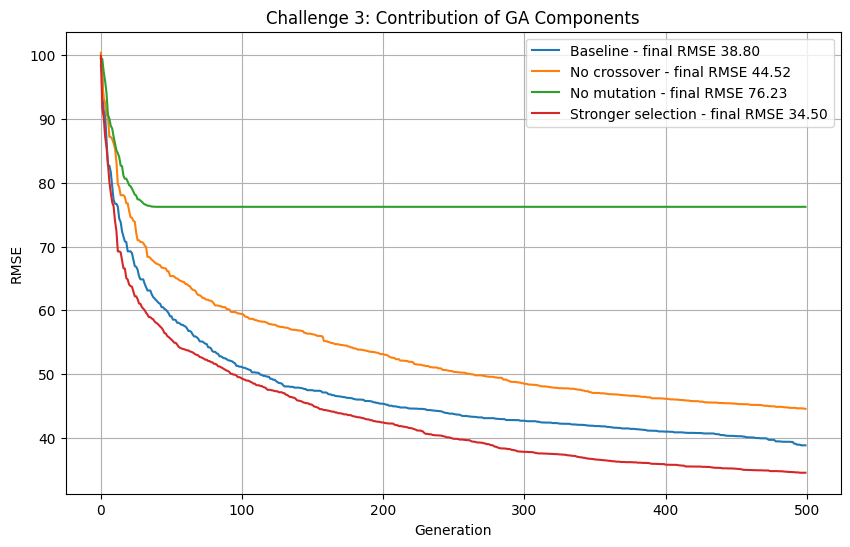

In [14]:
# Keep False by default so the notebook does not run long experiments accidentally.
# Set to True only when you want to run Challenge 3 experiments.
run_config_experiments = True

if run_config_experiments:
    # Load the same target image used in the main GA run.
    user = str(input("Select user (joao/goncalo): ").lower())
    if user == "joao":
        target_path = r"C:\Users\joaoa\Desktop\CIFO\data\girl_pearl_earing.png"
    elif user == "goncalo":
        target_path = r"C:\CIfO\Project\data\girl_pearl_earing.png"
    target = cv2.imread(target_path)

    # Stop if the target image cannot be loaded.
    if target is None:
        raise FileNotFoundError(
            f"OpenCV could not find the image at: {target_path}"
        )

    # Run Challenge 3 with smaller values first because this can take a long time.
    challenge3_results = run_challenge3_experiments(
        target, pop_size=100, generations=500, pc=0.85, pm=0.03, elitism_size=3
    )

    # Plot the convergence curves for comparison.
    plot_challenge3_results(challenge3_results)